# 04 — Churn Baseline & Logistic Regression

Time-aware validation setup: 5 quarterly training snapshots (2024-09-30 .. 2025-09-30), the most recent held out as validation for model selection, and the true final cutoff (`config.OBSERVATION_CUTOFF`, 2025-12-31) held out entirely until model selection is done — see `docs/model_card.md` 'Validation strategy' for why a random split would leak (the same customer can appear in multiple snapshots).

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
from data import config
from churn.dataset import build_training_pool, build_snapshot, feature_columns, LABEL_COLUMN

ROOT = '../data/raw'
customers = pd.read_parquet(f'{ROOT}/customers.parquet')
orders = pd.read_parquet(f'{ROOT}/orders.parquet')
interactions = pd.read_parquet(f'{ROOT}/interactions.parquet')
support = pd.read_parquet(f'{ROOT}/support.parquet')
products = pd.read_parquet(f'{ROOT}/products.parquet')

train_cutoffs = [pd.Timestamp(d) for d in
                 ['2024-09-30', '2024-12-31', '2025-03-31', '2025-06-30', '2025-09-30']]
pool = build_training_pool(customers, orders, interactions, support, products, train_cutoffs)

val_cutoff = train_cutoffs[-1]
train_pool = pool[pool['snapshot_cutoff'] != val_cutoff]
val_pool = pool[pool['snapshot_cutoff'] == val_cutoff]

test_cutoff = pd.Timestamp(config.OBSERVATION_CUTOFF)
test_pool = build_snapshot(customers, orders, interactions, support, products, test_cutoff)

feat_cols = feature_columns(pool)
X_train, y_train = train_pool[feat_cols], train_pool[LABEL_COLUMN]
X_val, y_val = val_pool[feat_cols], val_pool[LABEL_COLUMN]
X_test, y_test = test_pool[feat_cols], test_pool[LABEL_COLUMN]

print('train:', X_train.shape, 'val:', X_val.shape, 'test:', X_test.shape)
print(f'churn rate -- train: {y_train.mean():.1%}  val: {y_val.mean():.1%}  test: {y_test.mean():.1%}')

train: (19974, 27) val: (5508, 27) test: (5097, 27)
churn rate -- train: 24.0%  val: 28.1%  test: 28.6%


## Baseline: predict the training churn rate for everyone

The minimum benchmark any real model must beat.

In [2]:
from churn.train import train_baseline, predict_churn_probability
from churn.evaluate import evaluate_churn_model

baseline = train_baseline(X_train, y_train)
baseline_val = evaluate_churn_model(y_val, predict_churn_probability(baseline, X_val))
{k: round(v, 3) if isinstance(v, float) else v for k, v in baseline_val.items()}

{'roc_auc': 0.5,
 'pr_auc': 0.281,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'brier_score': 0.204,
 'precision_at_10pct': 0.271,
 'lift_at_10pct': np.float64(0.965),
 'true_positives': 0,
 'false_positives': 0,
 'true_negatives': 3962,
 'false_negatives': 1546,
 'base_churn_rate': 0.281,
 'threshold': 0.5}

ROC-AUC of 0.5 and zero precision/recall at the 0.5 threshold are expected and correct — the baseline outputs the same probability for every customer, so it has no ranking power at all. Any model that doesn't clear this is worthless.

## Logistic Regression — interpretable reference model

In [3]:
from churn.train import train_logistic_regression

logistic = train_logistic_regression(X_train, y_train)
logistic_val = evaluate_churn_model(y_val, predict_churn_probability(logistic, X_val))
{k: round(v, 3) if isinstance(v, float) else v for k, v in logistic_val.items()}

{'roc_auc': 0.855,
 'pr_auc': 0.698,
 'precision': 0.53,
 'recall': 0.829,
 'f1': 0.646,
 'brier_score': 0.174,
 'precision_at_10pct': 0.802,
 'lift_at_10pct': np.float64(2.857),
 'true_positives': 1282,
 'false_positives': 1139,
 'true_negatives': 2823,
 'false_negatives': 264,
 'base_churn_rate': 0.281,
 'threshold': 0.5}

## Logistic regression coefficients (direction of effect)

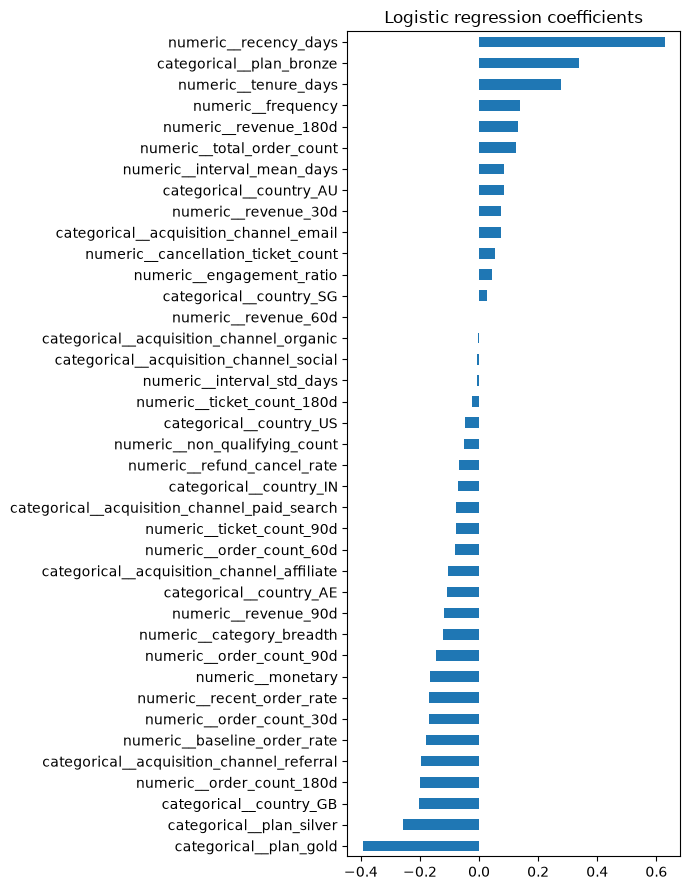

In [4]:
pre = logistic.named_steps['preprocess']
coef = pd.Series(logistic.named_steps['model'].coef_[0], index=pre.get_feature_names_out())
coef.sort_values().plot(kind='barh', figsize=(7, 9), title='Logistic regression coefficients')
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

Positive coefficients push toward churn, negative push toward retention. This is the interpretable reference point Phase 5's ensemble models (`05_churn_models.ipynb`) get compared against — not just on accuracy, but on whether the more complex models' predictions make similar directional sense.